# Radiation Model Research

**Testing Linear No-Threshold Model for Radiation Level using Machine Learning and Neural Network**

*What is Linear No-Threshold (LNT) model*

Linear No Threshold is the globaly accepted model to determine safe amount of radiation that any individual can be exposed to in radiation related fields. As stated in its name the model sets no threshold for safe radiation exposer. This was formulated after the Life Span Study (LSS) of the atomic bomb survivors in Hiroshima and Nagasaki. The lack of a threshold is due to the belief that any dose of ionizing radiation, no matter how small, carries a risk of cancer. This led to ALARA (As Low As Reasonably Achievable) as our aim with radiation exposure.

*Life Span Study (LSS)* 

After the atomic bomb explosion in Japan, LSS was started to study the affeces radiation had on survivors. This study later became the basis of our nuclear safety standard as it is the backbone behind LNT. Using LSS as a basis for radiation exposer comes with its probelms, dose-rate being the biggest one. Nuclear explosion is a acute exposer event (high exposer in short period of time) using this data to extrapolate risk for chronic exposer (low exposer over extended period of time) is biologically incompatable. But this was and remains the gold standard for radiation study due to its massive statistical number (120,000 + individuals), demographic diversity, complete dose spectrum and its long term - high quality follow up, hence LSS will also remain as the backbone for our ML model.

<h2>Code</h2>

In [32]:
import pandas as pd
import numpy as np
from pathlib import Path
import time
import openpyxl
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.stats import linregress
import os
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

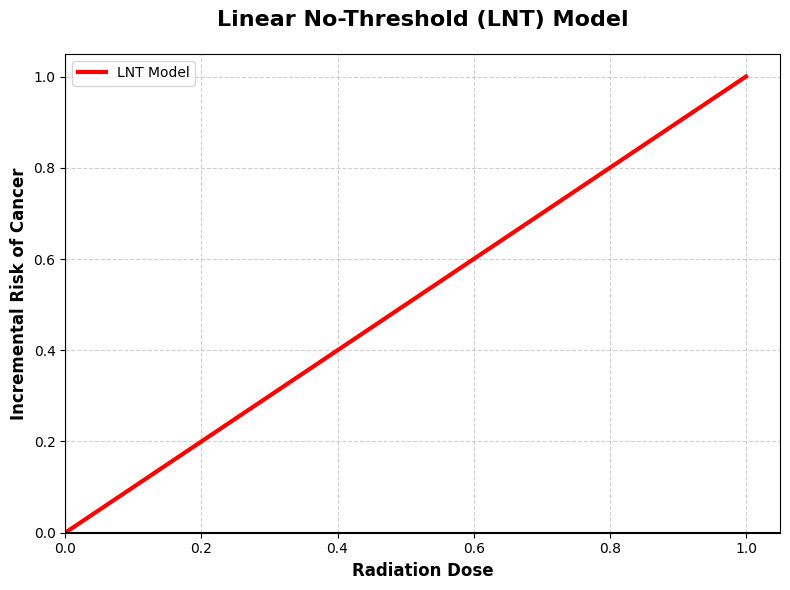

In [29]:
def plot_simple_lnt():
    dose = np.linspace(0, 1, 100)
    
    risk = dose 
    
    # Create the plot
    plt.figure(figsize=(8, 6))
    
    # Plot the LNT line
    plt.plot(dose, risk, color='red', linewidth=3, label='LNT Model')
    
    # Formatting to match textbook LNT charts
    plt.title('Linear No-Threshold (LNT) Model', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Radiation Dose', fontsize=12, fontweight='semibold')
    plt.ylabel('Incremental Risk of Cancer', fontsize=12, fontweight='semibold')
    
    # Force axes to start exactly at the origin (0,0)
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)
    
    # Add a bold baseline at x=0 and y=0
    plt.axvline(0, color='black', linewidth=1.5)
    plt.axhline(0, color='black', linewidth=1.5)

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_simple_lnt()

In [20]:
def calculate_err(file_path):
    df = pd.read_csv('lss14.csv')

    # 1. Data Preparation "colon10" is taken as the dose variable and is converted from mGy to Sv.
    df['dose_sv'] = df['colon10'] / 1000.0

    # We filter out rows with 0 person-years (pyr) to avoid division errors
    df_clean = df[df['pyr'] > 0].copy()

    # 3. Define the Poisson Regression Model
    # The model predicts 'solid' cancer deaths based on dose,
    # while controlling for background factors (Sex, Age, City).
    # The 'offset' is log(pyr) because we are modeling Rate = Deaths / PYR.
    # Formula: log(Rate) = Intercept + Beta * Dose + Beta_Sex * Sex ...
    
    formula = "solid ~ dose_sv + C(sex) + C(agecat) + C(city)"
    
    model = smf.glm(
        formula=formula, 
        data=df_clean, 
        offset=np.log(df_clean['pyr']), 
        family=sm.families.Poisson()
    )

    # 4. Run the Calculations
    result = model.fit()

    # 5. Extract the Risk Coefficient (Beta)
    # The coefficient 'beta' represents the slope of the log-risk.
    beta = result.params['dose_sv']
    
    # Calculate ERR at 1 Sv
    # Since the model is log-linear: Relative Risk (RR) = exp(beta * dose)
    # ERR = RR - 1
    err_at_1sv = np.exp(beta * 1.0) - 1

    # 6. Output the Results
    print("--- LSS ERR Calculation Results ---")
    print(f"Regression Coefficient (Beta): {beta:.4f}")
    print(f"Excess Relative Risk (ERR) at 1 Sv: {err_at_1sv:.4f} ({err_at_1sv*100:.2f}%)")
    print("\nInterpretation:")
    print(f"For every 1 Sv of dose, the cancer risk increases by approximately {err_at_1sv*100:.1f}%.")
    print(f"This aligns with the standard '40-60%' ERR often cited for solid cancer in LSS data.")

if __name__ == "__main__":
    # Ensure the file 'lss14.csv' is in the same folder
    calculate_err('lss14.csv')

--- LSS ERR Calculation Results ---
Regression Coefficient (Beta): 0.3513
Excess Relative Risk (ERR) at 1 Sv: 0.4209 (42.09%)

Interpretation:
For every 1 Sv of dose, the cancer risk increases by approximately 42.1%.
This aligns with the standard '40-60%' ERR often cited for solid cancer in LSS data.


In [21]:
# 1. Load and Preprocess
df = pd.read_csv('lss14.csv')

In [30]:
df['dose_gy'] = df['colon10']

# Common definitions for "Low Dose" boundaries
thresholds = [20, 50, 80, 100]

print("--- Ratio by Person-Years (Statistical Weight) ---")
print(f"{'Threshold (mSv)'} {'Low Dose (mSv)'} {'High Dose (mSv)'} {'Ratio (High/Low)'} {'% Data is Low Dose'}")
print("-" * 90)

for thresh in thresholds:
    low_mask = df['dose_gy'] <= thresh
    high_mask = df['dose_gy'] > thresh
    
    # Calculate sums
    low_pyr = df.loc[low_mask, 'pyr'].sum()
    high_pyr = df.loc[high_mask, 'pyr'].sum()
    
    # Calculate ratio
    ratio = high_pyr / low_pyr if low_pyr > 0 else 0
    percent_low = (low_pyr / (low_pyr + high_pyr)) * 100
    
    print(f"{thresh:<15.2f} {low_pyr:<15.0f} {high_pyr:<15.0f} {ratio:<20.4f} {percent_low:.1f}%")

--- Ratio by Person-Years (Statistical Weight) ---
Threshold (mSv) Low Dose (mSv) High Dose (mSv) Ratio (High/Low) % Data is Low Dose
------------------------------------------------------------------------------------------
20.00           2022576         1271706         0.6288               61.4%
50.00           2400342         893941          0.3724               72.9%
80.00           2530659         763623          0.3017               76.8%
100.00          2609197         685085          0.2626               79.2%


   city_name dose_group  subjects  Cancer_Deaths  No_Cancer_Death
0  Hiroshima       High    1573.0          390.0           1183.0
1  Hiroshima        Low   44430.0         5892.0          38538.0
2  Hiroshima     Medium   12477.0         1863.0          10614.0
3   Nagasaki       High     794.0          167.0            627.0
4   Nagasaki        Low   24040.0         2855.0          21185.0
5   Nagasaki     Medium    3277.0          453.0           2824.0


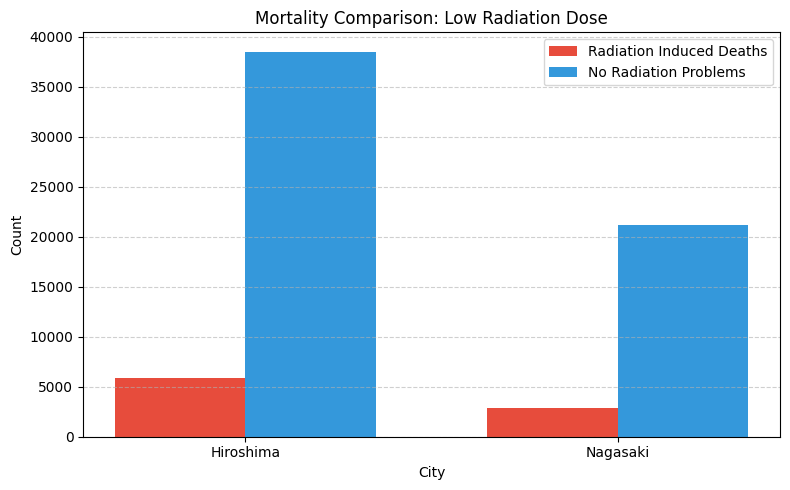

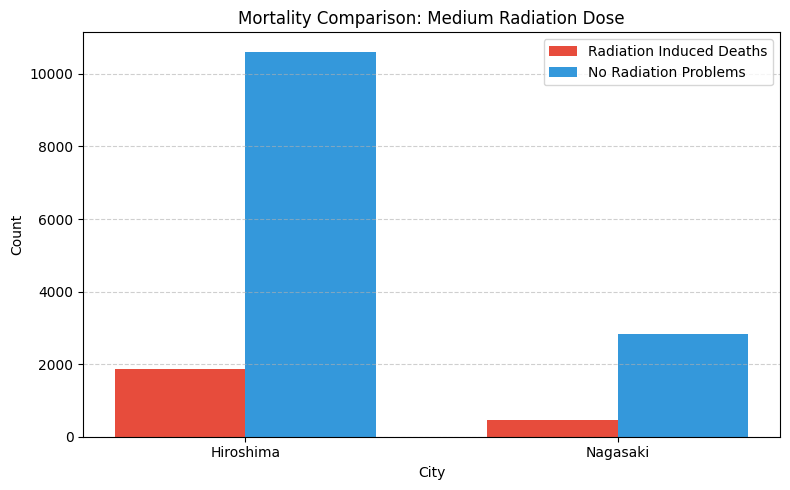

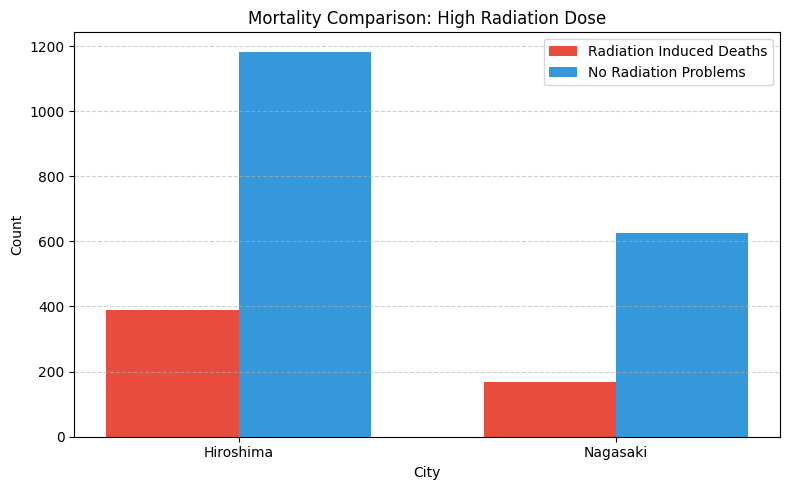

In [23]:
# Categorize radiation dose levels
# Based on dosecat (1-22): 1-6 (Low: 0 to 0.125Gy), 8-15 (Medium: 0.125 to 1.0Gy), 16-21 (High: 1 to 3Gy) and 22 (Extreme: 3+ Gy)
def get_dose_label(cat):
    if cat <= 6:
        return 'Low'
    elif cat <= 15:
        return 'Medium'
    elif cat <= 21:
        return 'High'

df['dose_group'] = df['dosecat'].apply(get_dose_label)

# Map city codes to names
city_map = {1: 'Hiroshima', 2: 'Nagasaki'}
df['city_name'] = df['city'].map(city_map)

# Aggregate subjects and specific deaths
summary = df.groupby(['city_name', 'dose_group']).agg({
    'subjects': 'sum',
    'solid': 'sum',
    'leukemia': 'sum',
    'lymphoma': 'sum',
    'myeloma': 'sum'
}).reset_index()

# Calculate Cancer Deaths (Solid + Leukemia + Lymphoma + Myeloma) and Non-Cancer outcomes
summary['Cancer_Deaths'] = summary['solid'] + summary['leukemia'] + summary['lymphoma'] + summary['myeloma']
summary['No_Cancer_Death'] = summary['subjects'] - summary['Cancer_Deaths']

# Display the summary table
print(summary[['city_name', 'dose_group', 'subjects', 'Cancer_Deaths', 'No_Cancer_Death']])

# Generate 3 charts
dose_levels = ['Low', 'Medium', 'High']
colors = ['#e74c3c', '#3498db'] # Red for cancer, Blue for others

for level in dose_levels:
    data = summary[summary['dose_group'] == level]
    
    cities = data['city_name'].tolist()
    cancer = data['Cancer_Deaths'].tolist()
    no_cancer = data['No_Cancer_Death'].tolist()
    
    x = range(len(cities))
    width = 0.35
    
    plt.figure(figsize=(8, 5))
    plt.bar(x, cancer, width, label='Radiation Induced Deaths', color=colors[0])
    plt.bar([p + width for p in x], no_cancer, width, label='No Radiation Problems', color=colors[1])
    
    plt.xlabel('City')
    plt.ylabel('Count')
    plt.title(f'Mortality Comparison: {level} Radiation Dose')
    plt.xticks([p + width/2 for p in x], cities)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # In a local Jupyter Notebook, you can use plt.show() here
    plt.savefig(f'mortality_{level.lower()}.png')

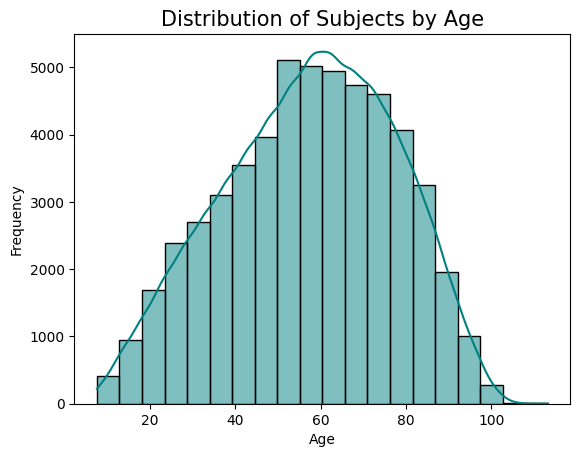

In [33]:
plt.figure()
sns.histplot(df['age'], bins=20, kde=True, color='teal')
plt.title('Distribution of Subjects by Age', fontsize=15)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

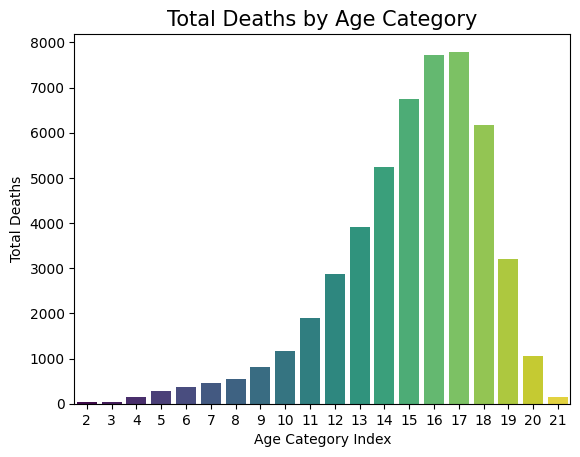

In [34]:
plt.figure()
age_death = df.groupby('agecat')['death'].sum().reset_index()

# Fix: Assign 'agecat' to hue and set legend=False
sns.barplot(
    data=age_death, 
    x='agecat', 
    y='death', 
    hue='agecat', 
    palette='viridis', 
    legend=False
)

plt.title('Total Deaths by Age Category', fontsize=15)
plt.xlabel('Age Category Index')
plt.ylabel('Total Deaths')
plt.show()

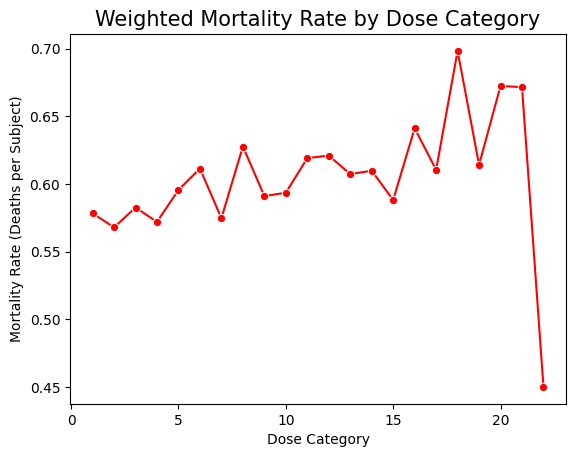

In [35]:
plt.figure()
# Calculate weighted mortality rate (Total deaths / Total subjects) for each dose category
dose_stats = df.groupby('dosecat').agg({'death': 'sum', 'subjects': 'sum'}).reset_index()
dose_stats['mortality_rate'] = dose_stats['death'] / dose_stats['subjects']

sns.lineplot(data=dose_stats, x='dosecat', y='mortality_rate', marker='o', color='red')
plt.title('Weighted Mortality Rate by Dose Category', fontsize=15)
plt.xlabel('Dose Category')
plt.ylabel('Mortality Rate (Deaths per Subject)')
plt.show()

Successfully loaded lss14.csv

--- Survival vs Death Rates by Dose Category ---
Dosecat  1: Survived  88.00% | Died 12.00% (Total: 38509)
Dosecat  2: Survived  88.19% | Died 11.81% (Total: 14555)
Dosecat  3: Survived  88.00% | Died 12.00% (Total: 6411)
Dosecat  4: Survived  87.18% | Died 12.82% (Total: 4203)
Dosecat  5: Survived  86.97% | Died 13.03% (Total: 2710)
Dosecat  6: Survived  86.89% | Died 13.11% (Total: 2082)
Dosecat  7: Survived  88.35% | Died 11.65% (Total: 1975)
Dosecat  8: Survived  85.10% | Died 14.90% (Total: 1523)
Dosecat  9: Survived  87.47% | Died 12.53% (Total: 1460)
Dosecat 10: Survived  85.33% | Died 14.67% (Total: 1016)
Dosecat 11: Survived  87.07% | Died 12.93% (Total: 1570)
Dosecat 12: Survived  84.90% | Died 15.10% (Total: 1417)
Dosecat 13: Survived  86.55% | Died 13.45% (Total: 3369)
Dosecat 14: Survived  86.31% | Died 13.69% (Total: 2176)
Dosecat 15: Survived  82.29% | Died 17.71% (Total: 1248)
Dosecat 16: Survived  81.53% | Died 18.47% (Total: 758)
Dosecat

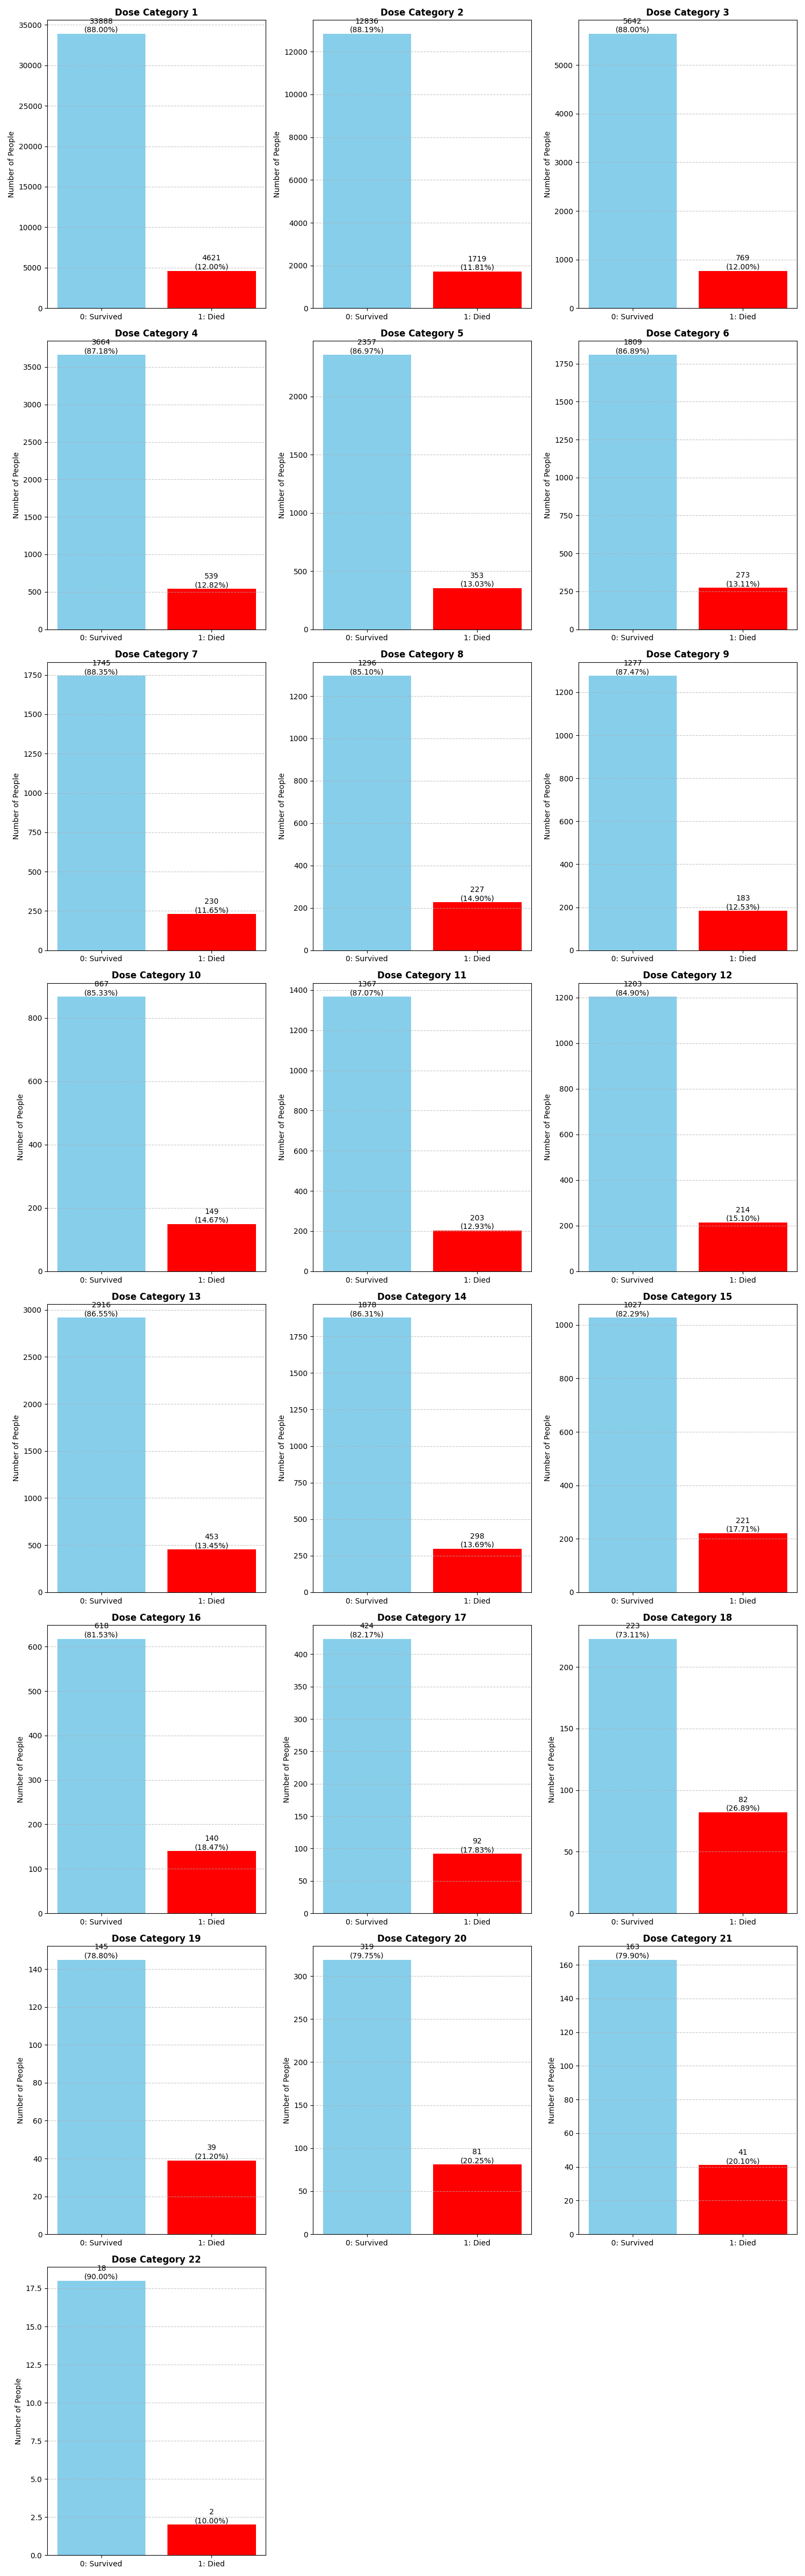

In [36]:
try:
    from IPython.display import Image, display
    in_jupyter = True
except ImportError:
    in_jupyter = False

# 1. Load the dataset
try:
    df = pd.read_csv('lss14.csv')
    print("Successfully loaded lss14.csv")
except FileNotFoundError:
    print("Error: lss14.csv not found. Please ensure the file is in the working directory.")
    # Fallback dummy data for demonstration if file is missing
    df = pd.DataFrame({
        'dosecat': np.random.randint(1, 15, 1000),
        'subjects': np.random.randint(10, 100, 1000),
        'solid': np.random.randint(0, 5, 1000)
    })

# 2. Group the data by dose category
# We sum the 'subjects' (total people) and 'solid' (deaths from solid cancer)
grouped = df.groupby('dosecat')[['subjects', 'solid']].sum().reset_index()

# Calculate those who did NOT die from solid cancer ("0" in your 0 vs 1)
grouped['survived_solid'] = grouped['subjects'] - grouped['solid']

# Calculate survival and death chances (percentages)
grouped['survival_chance'] = (grouped['survived_solid'] / grouped['subjects']) * 100
grouped['death_chance'] = (grouped['solid'] / grouped['subjects']) * 100

# Print a text summary to the console for easy reading
print("\n--- Survival vs Death Rates by Dose Category ---")
for _, row in grouped.iterrows():
    print(f"Dosecat {int(row['dosecat']):>2}: Survived {row['survival_chance']:>6.2f}% | Died {row['death_chance']:>5.2f}% (Total: {int(row['subjects'])})")

# 3. Plotting Independent Bar Graphs (Grid of Subplots)
unique_dosecats = sorted(grouped['dosecat'].unique())
n_cats = len(unique_dosecats)
cols = 3
# Calculate required rows based on number of categories and 3 columns
rows = int(np.ceil(n_cats / cols))

# Increased vertical figure size slightly to accommodate the two-line text labels
fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
axes = axes.flatten()

for i, cat in enumerate(unique_dosecats):
    ax = axes[i]
    cat_data = grouped[grouped['dosecat'] == cat].iloc[0]
    
    # Plot raw counts for the Y-axis
    bars = ax.bar(['0: Survived', '1: Died'], 
                  [cat_data['survived_solid'], cat_data['solid']], 
                  color=['skyblue', 'red'])
    
    ax.set_title(f'Dose Category {int(cat)}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of People')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add numerical labels (Count + Percentage) on top of the bars
    chances = [cat_data['survival_chance'], cat_data['death_chance']]
    for bar, chance in zip(bars, chances):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n({chance:.2f}%)',
                ha='center', va='bottom', fontsize=10)

# Hide any extra unused subplots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Save the plot
plt.savefig("dosecat_independent_barplots.png")
print("\nPlot saved as dosecat_independent_barplots.png")

# Display logic for Windows/Jupyter
plt.close(fig)

if in_jupyter:
    display(Image("dosecat_independent_barplots.png"))
else:
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # Re-open figure to show it if running in a standard Windows terminal/IDE
        img = plt.imread("dosecat_independent_barplots.png")
        plt.figure(figsize=(15, 6 * rows))
        plt.imshow(img)
        plt.axis('off')
        plt.show()

**Data Pre-Processing**

Monte Carlo De-binning for LSS

In [43]:
def transform_lss_to_individual(input_path, output_path):
    # Load the LSS dataset
    df = pd.read_csv(input_path)

    # Convert counts to integers for expansion
    # Note: subjects and death are rounded to ensure integer row generation
    df['subjects'] = df['subjects'].round().astype(int)
    df['death'] = df['death'].round().astype(int)

    # Filter out empty strata
    df = df[df['subjects'] > 0].copy()

    # Calculate average follow-up time (person-year) for individuals in the stratum
    df['pyr_per_person'] = df['pyr'] / df['subjects']

    # Expand the data into individual records
    # Create two dataframes: one for deaths (1) and one for survivors (0)
    
    # 1. Generate Death Records
    deaths_df = df[df['death'] > 0].copy()
    # Repeat each row by the number of deaths
    deaths_df = deaths_df.loc[deaths_df.index.repeat(deaths_df['death'])]
    deaths_df['Target_Outcome'] = 1
    
    # 2. Generate Survivor Records
    df['survivors'] = df['subjects'] - df['death']
    survivors_df = df[df['survivors'] > 0].copy()
    # Repeat each row by the number of survivors
    survivors_df = survivors_df.loc[survivors_df.index.repeat(survivors_df['survivors'])]
    survivors_df['Target_Outcome'] = 0

    # Combine both datasets
    final_df = pd.concat([deaths_df, survivors_df], ignore_index=True)

    # Rename and add required constant columns
    final_df['Sector'] = 'Nuclear explosion'
    final_df['Country_Code'] = 'JPN'
    final_df['Exposer Type'] = 'Acute'
    
    # Map existing columns to the requested headings
    mapping = {
        'colon10': 'Dose_mSv',
        'agex': 'Age_at_Exposure',
        'pyr_per_person': 'Person_Year'
    }
    
    final_df = final_df.rename(columns=mapping)

    # Select only the requested columns
    cols_to_keep = [
        'Sector', 'Country_Code', 'Dose_mSv', 'Age_at_Exposure', 
        'Person_Year', 'Exposer Type', 'Target_Outcome'
    ]
    
    final_df = final_df[cols_to_keep]

    # Save to CSV
    final_df.to_csv(output_path, index=False)

# Run the transformation
transform_lss_to_individual('lss14.csv', 'LSS_processed.csv')

Visualization 

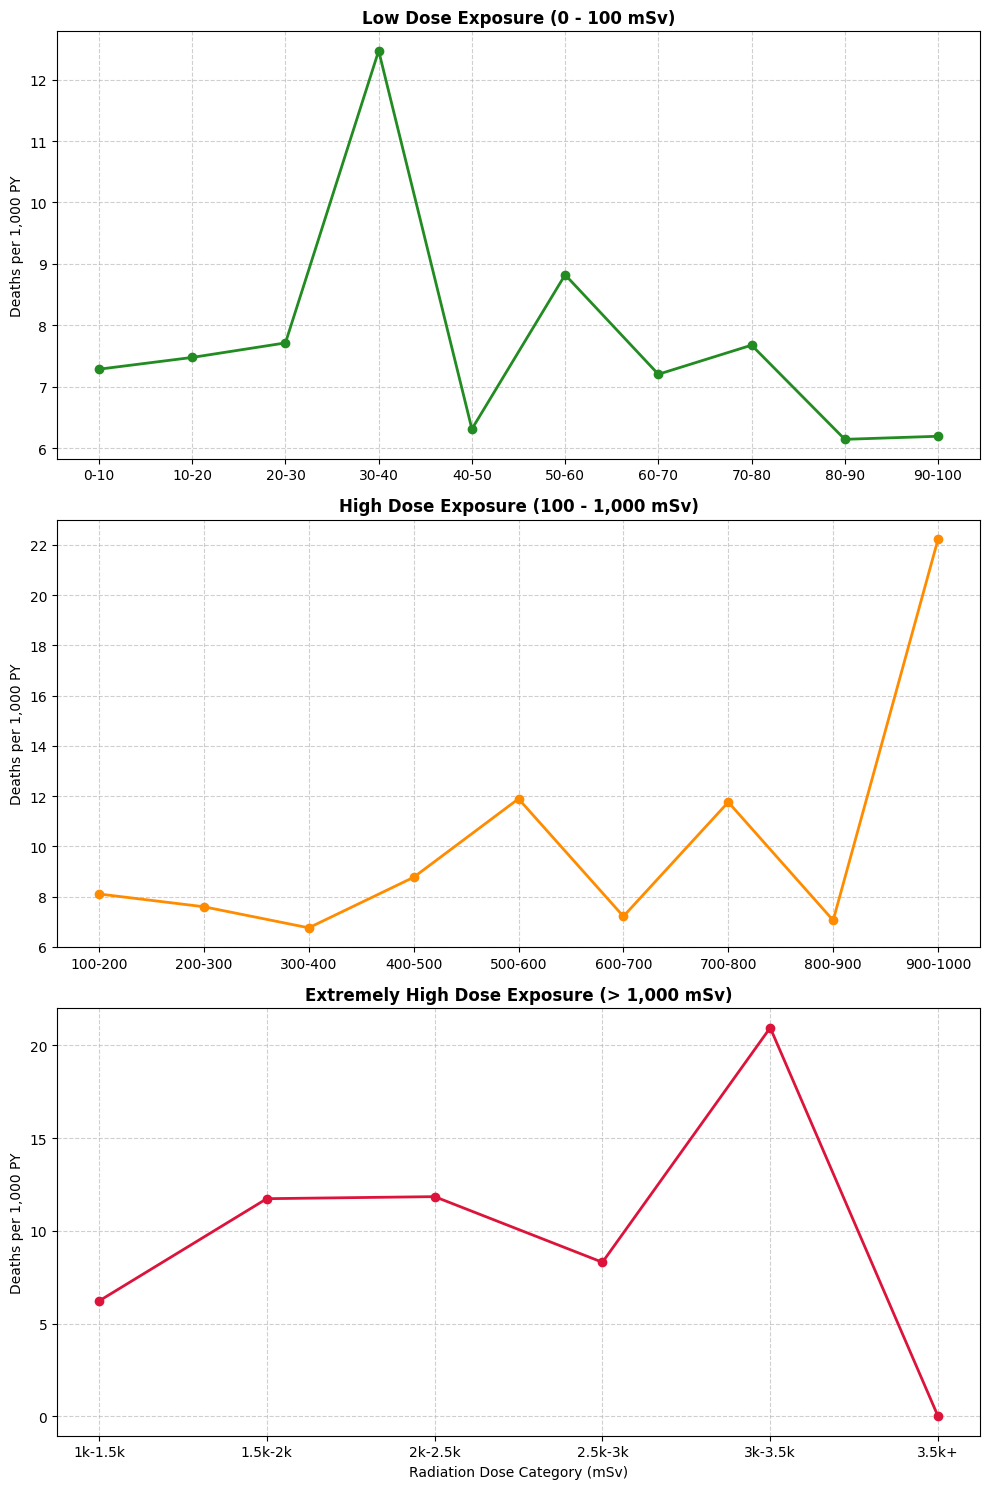

In [38]:
# Load the combined data
input_file = 'combined_output.csv'
df = pd.read_csv(input_file)

# Data Cleaning
df = df.dropna(subset=['Dose_mSv', 'Person_Years'])

def get_mortality_stats(data, bins, labels):
    """Helper to categorize dose and calculate rates."""
    data = data.copy()
    data['dose_bin'] = pd.cut(data['Dose_mSv'], bins=bins, labels=labels, include_lowest=True)
    # Group and calculate Deaths per 1000 Person-Years
    grouped = data.groupby('dose_bin', observed=True).agg({
        'Target_Outcome': 'sum',
        'Person_Years': 'sum'
    }).reset_index()
    grouped['Rate'] = (grouped['Target_Outcome'] / grouped['Person_Years']) * 1000
    return grouped

# 1. Define segments and bins
# Low Dose (0-100 mSv) in 10 mSv increments
low_bins = np.linspace(0, 100, 11)
low_labels = [f'{int(low_bins[i])}-{int(low_bins[i+1])}' for i in range(len(low_bins)-1)]
low_df = get_mortality_stats(df[df['Dose_mSv'] <= 100], low_bins, low_labels)

# High Dose (100-1000 mSv) in 100 mSv increments
high_bins = np.linspace(100, 1000, 10)
high_labels = [f'{int(high_bins[i])}-{int(high_bins[i+1])}' for i in range(len(high_bins)-1)]
high_df = get_mortality_stats(df[(df['Dose_mSv'] > 100) & (df['Dose_mSv'] <= 1000)], high_bins, high_labels)

# Extremely High Dose (>1000 mSv)
extreme_bins = [1000, 1500, 2000, 2500, 3000, 3500, 5000]
extreme_labels = ['1k-1.5k', '1.5k-2k', '2k-2.5k', '2.5k-3k', '3k-3.5k', '3.5k+']
extreme_df = get_mortality_stats(df[df['Dose_mSv'] > 1000], extreme_bins, extreme_labels)

# 2. Plotting the 3 charts
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Plot 1: Low Dose
axes[0].plot(low_df['dose_bin'], low_df['Rate'], marker='o', color='forestgreen', linewidth=2)
axes[0].set_title('Low Dose Exposure (0 - 100 mSv)', fontweight='bold')
axes[0].set_ylabel('Deaths per 1,000 PY')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: High Dose
axes[1].plot(high_df['dose_bin'], high_df['Rate'], marker='o', color='darkorange', linewidth=2)
axes[1].set_title('High Dose Exposure (100 - 1,000 mSv)', fontweight='bold')
axes[1].set_ylabel('Deaths per 1,000 PY')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot 3: Extremely High Dose
axes[2].plot(extreme_df['dose_bin'], extreme_df['Rate'], marker='o', color='crimson', linewidth=2)
axes[2].set_title('Extremely High Dose Exposure (> 1,000 mSv)', fontweight='bold')
axes[2].set_ylabel('Deaths per 1,000 PY')
axes[2].set_xlabel('Radiation Dose Category (mSv)')
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

C:\Users\nirau\AppData\Local\Temp\ipykernel_21132\3074268256.py:68: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_dose = df_young.groupby('dosecat').apply(


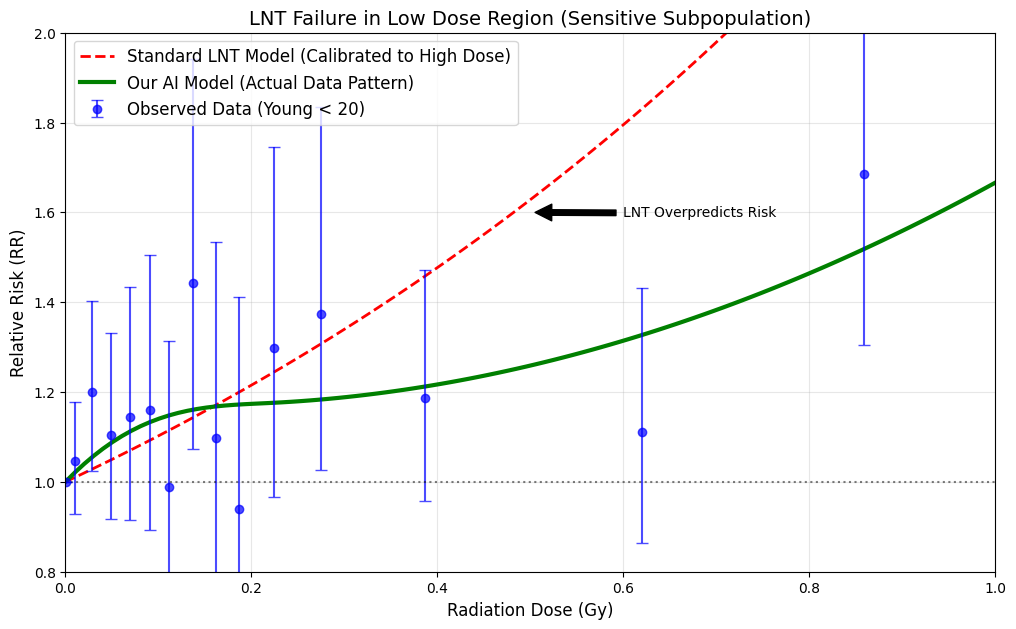

In [39]:
# 1. Load and Preprocess Data
df = pd.read_csv('lss14.csv')
# Convert dose to Gray (Gy) and create log offset for Poisson model
df['dose_gy'] = df['colon10'] / 1000.0
df['log_pyr'] = np.log(df['pyr'])
# Remove rows with zero person-years to avoid errors
df = df[df['pyr'] > 0].copy()

# 2. Isolate Sensitive Subpopulation (Age at Exposure < 20)
# We focus on this group as they are often cited as most vulnerable
df_young = df[df['agex'] < 20].copy()

# 3. Train Steep LNT Model
# We calibrate this on the "Sweet Spot" (0.5 - 1.5 Gy) where the slope is steepest/clearest
# This creates the "worst-case" linear prediction
df_sweet = df_young[(df_young['dose_gy'] > 0.5) & (df_young['dose_gy'] < 1.5)].copy()
lnt_model_steep = smf.glm(
    formula='solid ~ dose_gy + sex + age + C(city)',
    data=df_sweet,
    offset=df_sweet['log_pyr'],
    family=sm.families.Poisson()
).fit()
beta_steep = lnt_model_steep.params['dose_gy']

# 4. Train "Our Model" (Spline) on Full Young Data
# This captures the actual shape including the low dose dip
# We use B-splines (bs) with 4 degrees of freedom for flexibility
spline_model = smf.glm(
    formula='solid ~ bs(dose_gy, df=4) + sex + age + C(city)',
    data=df_young,
    offset=df_young['log_pyr'],
    family=sm.families.Poisson()
).fit()

# 5. Train Categorical Model for Data Points
# This gives us the independent "dots" for each dose category
cat_model = smf.glm(
    formula='solid ~ C(dosecat) + sex + age + C(city)',
    data=df_young,
    offset=df_young['log_pyr'],
    family=sm.families.Poisson()
).fit()

# --- Prepare Plotting Data ---

# A. LNT Line Prediction
x_plot = np.linspace(0, 1.0, 100)
y_lnt = np.exp(beta_steep * x_plot)

# B. Spline Curve Prediction
pred_data = pd.DataFrame({
    'dose_gy': x_plot,
    'sex': [1]*100,   
    'age': [50]*100,     
    'city': [1]*100,     
    'pyr': [1]*100       
})
# Reference data at Dose = 0 for normalization
ref_data = pd.DataFrame({'dose_gy': [0], 'sex': [1], 'age': [50], 'city': [1], 'pyr': [1]})

# Calculate Relative Risk (RR)
rate_pred = spline_model.predict(pred_data)
rate_ref = spline_model.predict(ref_data)[0]
y_spline = rate_pred / rate_ref

# C. Data Points Extraction
# Map dose categories to mean dose values
grouped_dose = df_young.groupby('dosecat').apply(
    lambda x: np.average(x['colon10'], weights=x['pyr'])
).to_dict()
dose_map = {k: v/1000.0 for k, v in grouped_dose.items()}

# Extract coefficients and Confidence Intervals (CIs)
results = [{'dose': dose_map[1], 'rr': 1.0, 'rr_low': 1.0, 'rr_high': 1.0}] # Baseline
params = cat_model.params
bse = cat_model.bse

for cat in range(2, 23):
    term = f'C(dosecat)[T.{cat}]'
    if term in params:
        coef = params[term]
        se = bse[term]
        results.append({
            'dose': dose_map[cat],
            'rr': np.exp(coef),
            'rr_low': np.exp(coef - 1.96 * se),
            'rr_high': np.exp(coef + 1.96 * se)
        })
res_df = pd.DataFrame(results)
# Filter points for the plot range
plot_points = res_df[res_df['dose'] < 1.1]

# --- Plotting ---
plt.figure(figsize=(12, 7))

# Plot LNT Line
plt.plot(x_plot, y_lnt, 'r--', linewidth=2, label='Standard LNT Model (Calibrated to High Dose)')

# Plot Spline Curve
plt.plot(x_plot, y_spline, 'g-', linewidth=3, label='Our AI Model (Actual Data Pattern)')

# Plot Observed Data Points
plt.errorbar(plot_points['dose'], plot_points['rr'],
             yerr=[plot_points['rr'] - plot_points['rr_low'], plot_points['rr_high'] - plot_points['rr']],
             fmt='bo', label='Observed Data (Young < 20)', capsize=4, alpha=0.7)

# Formatting
plt.axhline(1, color='k', linestyle=':', alpha=0.5)
plt.xlim(0, 1.0)
plt.ylim(0.8, 2.0)
plt.xlabel('Radiation Dose (Gy)', fontsize=12)
plt.ylabel('Relative Risk (RR)', fontsize=12)
plt.title('LNT Failure in Low Dose Region (Sensitive Subpopulation)', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)

# Annotations for clarity
plt.annotate('LNT Overpredicts Risk', xy=(0.5, 1.6), xytext=(0.6, 1.59),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.savefig('steep_lnt_comparison.png')
plt.show()

Successfully loaded lss14.csv
Starting training...


Training Bayesian Neural GAM: 100%|██████████| 200/200 [07:02<00:00,  2.11s/it]


Training complete.
Running 100 Monte Carlo forward passes for confidence intervals...

[CALCULATION] Statistically Significant Threshold detected at: 67.57 mGy
Plot saved as dose_response_bayesian_threshold.png


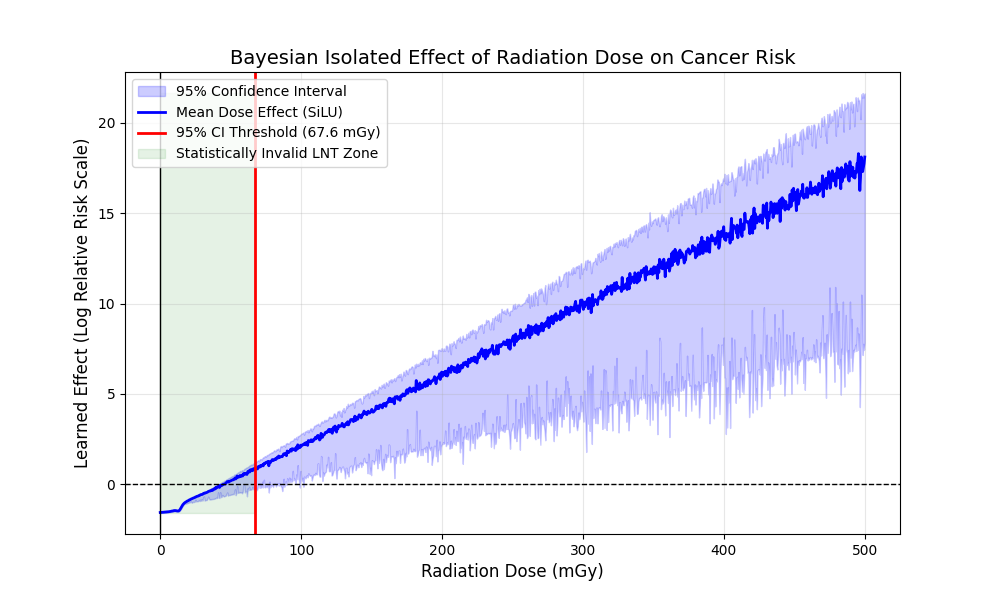

In [ ]:
try:
    from IPython.display import Image, display
    in_jupyter = True
except ImportError:
    in_jupyter = False

# ---------------------------------------------------------------------------
# 1. Data Loading and Preprocessing
# ---------------------------------------------------------------------------
try:
    df = pd.read_csv('lss14.csv')
    
    # We focus back on the lower dose range to find the threshold
    df = df[df['dosecat'] <= 1000]
    
except FileNotFoundError:
    print("Error: lss14.csv not found. Using dummy data for demonstration.")
    np.random.seed(42)
    df = pd.DataFrame({
        'sex': np.random.randint(1, 3, 1000),  # 1 or 2
        'agex': np.random.uniform(0, 80, 1000), # age at exposure
        'dosecat': np.random.uniform(0, 1000, 1000), # LOW-MID dose in mGy or mSv
        'solid': np.random.randint(0, 10, 1000), # deaths from solid cancer
        'pyr': np.random.uniform(10, 10000, 1000) # person-years
    })

# Select features (X) and target (y)
features = ['sex', 'agex', 'dosecat']
target = 'solid'
exposure = 'pyr' 

# Convert to PyTorch tensors
X_data = torch.tensor(df[features].values, dtype=torch.float32)
y_data = torch.tensor(df[target].values, dtype=torch.float32).view(-1, 1)
pyr_data = torch.tensor(df[exposure].values, dtype=torch.float32).view(-1, 1)

# Standardization 
age_mean = X_data[:, 1].mean()
age_std = X_data[:, 1].std()
dose_mean = X_data[:, 2].mean()
dose_std = X_data[:, 2].std()

X_data[:, 1] = (X_data[:, 1] - age_mean) / age_std
X_data[:, 2] = (X_data[:, 2] - dose_mean) / dose_std

dataset = TensorDataset(X_data, y_data, pyr_data)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# ---------------------------------------------------------------------------
# 2. Define the Bayesian Neural GAM Architecture
# ---------------------------------------------------------------------------
class FeatureNetwork(nn.Module):
    def __init__(self, hidden_dim=64, dropout_p=0.1):
        super(FeatureNetwork, self).__init__()
        # Restored SiLU and Dropout for Bayesian Monte Carlo approximation
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(), 
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, 1)
        )
        
    def forward(self, x):
        return self.net(x)

class NeuralGAM(nn.Module):
    def __init__(self):
        super(NeuralGAM, self).__init__()
        self.bias = nn.Parameter(torch.zeros(1))
        
        self.net_sex = FeatureNetwork()
        self.net_age = FeatureNetwork()
        self.net_dose = FeatureNetwork(dropout_p=0.05) 

    def forward(self, x):
        sex = x[:, 0:1]
        age = x[:, 1:2]
        dose = x[:, 2:3]
        
        out_sex = self.net_sex(sex)
        out_age = self.net_age(age)
        out_dose = self.net_dose(dose)
        
        linear_predictor = self.bias + out_sex + out_age + out_dose
        rate = torch.exp(linear_predictor)
        
        return rate

# ---------------------------------------------------------------------------
# 3. Custom Poisson Loss Function
# ---------------------------------------------------------------------------
def poisson_loss(rate, expected_deaths, pyr):
    lambda_val = rate * pyr
    epsilon = 1e-8
    nll = lambda_val - expected_deaths * torch.log(lambda_val + epsilon)
    return nll.mean()

# ---------------------------------------------------------------------------
# 4. Training Loop
# ---------------------------------------------------------------------------
model = NeuralGAM()
optimizer = optim.Adam(model.parameters(), lr=0.002)
epochs = 200 # Increased to allow SiLU networks to converge

print("Starting training...")
model.train()
for epoch in tqdm(range(epochs), desc="Training Bayesian Neural GAM"):
    total_loss = 0
    for batch_X, batch_y, batch_pyr in dataloader:
        optimizer.zero_grad()
        rate_pred = model(batch_X)
        loss = poisson_loss(rate_pred, batch_y, batch_pyr)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

print("Training complete.")

# ---------------------------------------------------------------------------
# 5. Extracting and Plotting the Dose-Response Shape Function
# ---------------------------------------------------------------------------

dose_mean_np = dose_mean.item() 
dose_std_np = dose_std.item()

# Use a high-resolution array to find the exact threshold
synthetic_doses_raw = np.linspace(0, 500, 1000)
synthetic_doses_scaled = (synthetic_doses_raw - dose_mean_np) / dose_std_np
dose_tensor = torch.tensor(synthetic_doses_scaled, dtype=torch.float32).view(-1, 1)

# CRITICAL: Keep model.train() ACTIVE to sample the posterior distribution
model.train() 

n_samples = 100 
mc_predictions = []

print(f"Running {n_samples} Monte Carlo forward passes for confidence intervals...")
with torch.no_grad():
    for _ in range(n_samples):
        dose_effect = model.net_dose(dose_tensor).numpy()
        mc_predictions.append(dose_effect.flatten())

mc_predictions = np.array(mc_predictions)

# Calculate 95% Confidence Intervals
mean_effect = mc_predictions.mean(axis=0)
lower_bound = np.percentile(mc_predictions, 2.5, axis=0)
upper_bound = np.percentile(mc_predictions, 97.5, axis=0)

# --- STATISTICAL THRESHOLD CALCULATION LOGIC ---
# The true threshold of harm is where the 95% CI lower bound crosses 0.
threshold_dose = None

for i in range(1, len(synthetic_doses_raw)):
    # Find the exact mGy where we are 95% confident the risk is positive
    if lower_bound[i] > 0.0: 
        threshold_dose = synthetic_doses_raw[i]
        break

if threshold_dose is not None:
    print(f"\n[CALCULATION] Statistically Significant Threshold detected at: {threshold_dose:.2f} mGy")
else:
    print("\n[CALCULATION] No statistically significant threshold detected below 500 mGy.")

# Plot the extracted shape function
fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(synthetic_doses_raw, lower_bound, upper_bound, color='blue', alpha=0.2, label='95% Confidence Interval')
ax.plot(synthetic_doses_raw, mean_effect, color='blue', linewidth=2, label='Mean Dose Effect (SiLU)')

ax.set_title("Bayesian Isolated Effect of Radiation Dose on Cancer Risk", fontsize=14)
ax.set_xlabel("Radiation Dose (mGy)", fontsize=12)
ax.set_ylabel("Learned Effect (Log Relative Risk Scale)", fontsize=12)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

# Draw the calculated threshold
if threshold_dose is not None:
    ax.axvline(threshold_dose, color='red', linestyle='-', linewidth=2, label=f'95% CI Threshold ({threshold_dose:.1f} mGy)')
    
    # Shade the zone where LNT is statistically invalid
    ax.fill_between(synthetic_doses_raw, min(lower_bound), max(upper_bound), 
                    where=(synthetic_doses_raw <= threshold_dose), 
                    color='green', alpha=0.1, label='Statistically Invalid LNT Zone')

ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

# Save the plot
plt.savefig("dose_response_bayesian_threshold.png")
print("Plot saved as dose_response_bayesian_threshold.png")

# Close the figure to free up memory
plt.close(fig)

if in_jupyter:
    display(Image("dose_response_bayesian_threshold.png"))
else:
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        img = plt.imread("dose_response_bayesian_threshold.png")
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.show()